Greedy Selection: [{'id': 1, 'value': 100, 'weight': 5}, {'id': 2, 'value': 60, 'weight': 3}]
DP Result: 180
Dijkstra: {'A': 0, 'B': 10, 'C': 15, 'D': 20}
TSP Cost: 80


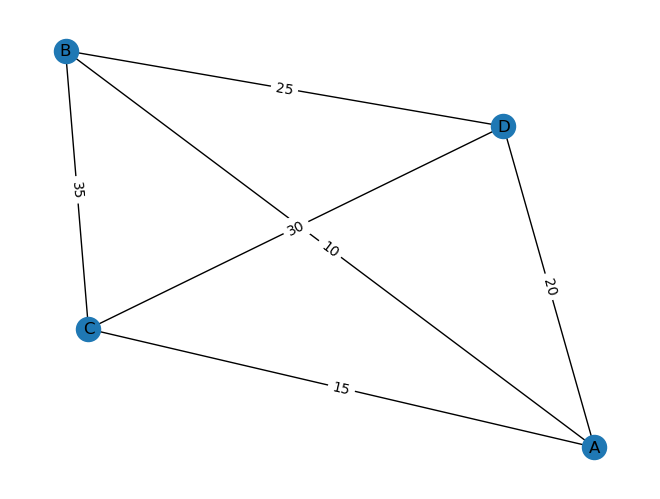

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq
from itertools import permutations

graph = {
    'A': {'B': 10, 'C': 15, 'D': 20},
    'B': {'A': 10, 'C': 35, 'D': 25},
    'C': {'A': 15, 'B': 35, 'D': 30},
    'D': {'A': 20, 'B': 25, 'C': 30}
}

parcels = [
    {"id": 1, "value": 100, "weight": 5},
    {"id": 2, "value": 60, "weight": 3},
    {"id": 3, "value": 120, "weight": 7}
]

max_capacity = 10

def greedy_selection(parcels, capacity):
    parcels.sort(key=lambda x: x['value']/x['weight'], reverse=True)
    selected = []
    total_weight = 0

    for p in parcels:
        if total_weight + p['weight'] <= capacity:
            selected.append(p)
            total_weight += p['weight']

    return selected

print("Greedy Selection:", greedy_selection(parcels, max_capacity))

def knapsack(parcels, capacity):
    n = len(parcels)
    dp = [[0]*(capacity+1) for _ in range(n+1)]

    for i in range(1, n+1):
        for w in range(capacity+1):
            if parcels[i-1]['weight'] <= w:
                dp[i][w] = max(dp[i-1][w],
                               parcels[i-1]['value'] + dp[i-1][w - parcels[i-1]['weight']])
            else:
                dp[i][w] = dp[i-1][w]

    return dp[n][capacity]

print("DP Result:", knapsack(parcels, max_capacity))

def dijkstra(graph, start):
    pq = [(0, start)]
    distances = {node: float('inf') for node in graph}
    distances[start] = 0

    while pq:
        dist, node = heapq.heappop(pq)

        for neighbor in graph[node]:
            new_dist = dist + graph[node][neighbor]
            if new_dist < distances[neighbor]:
                distances[neighbor] = new_dist
                heapq.heappush(pq, (new_dist, neighbor))

    return distances

print("Dijkstra:", dijkstra(graph, 'A'))

def tsp(graph):
    nodes = list(graph.keys())
    start = 'A'
    nodes.remove(start)

    min_cost = float('inf')

    for perm in permutations(nodes):
        cost = 0
        current = start

        for node in perm:
            cost += graph[current][node]
            current = node

        cost += graph[current][start]
        min_cost = min(min_cost, cost)

    return min_cost

print("TSP Cost:", tsp(graph))
G = nx.Graph()

for node in graph:
    for neighbor in graph[node]:
        G.add_edge(node, neighbor, weight=graph[node][neighbor])

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.show()